# Use Case 2: Fare Prediction Before Ride Initiation

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to understand the characteristics of taxi fares and identify important factors influencing fare amounts before ride initiation.

The insights derived from exploratory analysis will guide feature engineering and model development.

Specifically, this notebook aims to:

- Understand the distribution of fare amounts.
- Detect potential outliers.
- Explore relationships between fare amount and numerical features.
- Investigate temporal patterns affecting fares.
- Examine geographical influences on fare estimation.
- Identify features suitable for predictive modeling while avoiding data leakage.

# 1. Import Required Libraries

Import libraries required for:

- Data manipulation and analysis
- Data visualization
- Statistical analysis
- Warning suppression

In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

# 2. Load Dataset

Load the cleaned taxi dataset generated during the preprocessing stage.

In [16]:
df = pd.read_parquet("/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE2_Trip_Fare_Forecasting/data/cleaned_taxi_data.parquet")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (3499962, 10)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,cbd_congestion_fee,trip_duration
0,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,239,238,7.2,0.00,5.550000
1,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,142,209,38.7,0.75,42.800000
2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,144,137,14.2,0.75,13.600000
3,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,142,50,11.4,0.75,10.633333
4,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,161,45,37.3,0.75,37.733333


# 3. Dataset Overview

Inspect dataset structure, data types, and missing values.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3499962 entries, 0 to 3499961
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   RatecodeID             float64       
 5   PULocationID           int32         
 6   DOLocationID           int32         
 7   fare_amount            float64       
 8   cbd_congestion_fee     float64       
 9   trip_duration          float64       
dtypes: datetime64[us](2), float64(6), int32(2)
memory usage: 240.3 MB


In [18]:
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_amount,cbd_congestion_fee,trip_duration
count,3499962,3499962,3.499962e+06,3.499962e+06,2.505383e+06,3.499962e+06,3.499962e+06,3.499962e+06,3.499962e+06,3.499962e+06
mean,2026-01-17 00:51:03.487804,2026-01-17 01:08:10.202258,1.186869e+00,3.482794e+00,5.359114e+00,1.614953e+02,1.610548e+02,2.102097e+01,5.319443e-01,1.711191e+01
min,2025-12-31 23:57:29,2025-12-31 23:57:32,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,0.000000e+00,1.666667e-02
25%,2026-01-09 17:35:59,2026-01-09 17:54:11.250000,1.000000e+00,1.090000e+00,1.000000e+00,1.140000e+02,1.070000e+02,1.000000e+01,0.000000e+00,8.333333e+00
50%,2026-01-16 20:57:27.500000,2026-01-16 21:13:05.500000,1.000000e+00,1.900000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.560000e+01,7.500000e-01,1.353333e+01
75%,2026-01-24 03:41:31.500000,2026-01-24 03:54:22,1.000000e+00,3.890000e+00,1.000000e+00,2.330000e+02,2.340000e+02,2.610000e+01,7.500000e-01,2.133333e+01
max,2026-02-01 00:45:01,2026-02-01 01:03:08,6.000000e+00,9.510000e+01,9.900000e+01,2.650000e+02,2.650000e+02,2.000000e+02,7.500000e-01,1.799667e+02
std,NaN,NaN,5.730377e-01,4.195791e+00,2.001898e+01,6.702233e+01,7.102249e+01,1.676218e+01,3.405782e-01,1.375306e+01


In [19]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values[
    missing_values > 0
]

RatecodeID    994579
dtype: int64

# 4. Target Variable Analysis: Fare Amount Distribution

Understanding the target variable distribution helps identify:

- Central tendency
- Spread of values
- Skewness
- Potential need for transformations

In [20]:
df["fare_amount"].describe()

count    3.499962e+06
mean     2.102097e+01
std      1.676218e+01
min      1.000000e-02
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.000000e+02
Name: fare_amount, dtype: float64

In [21]:
print(
    "Skewness:",
    df["fare_amount"].skew()
)

print(
    "Kurtosis:",
    df["fare_amount"].kurtosis()
)

Skewness: 2.281923148322982
Kurtosis: 7.880601667297826


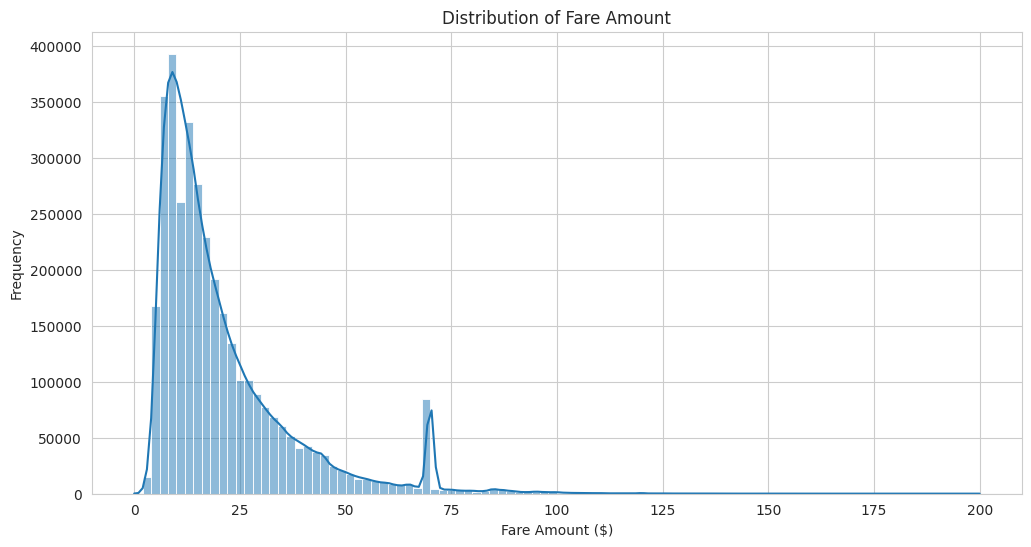

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["fare_amount"],
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Fare Amount"
)

plt.xlabel(
    "Fare Amount ($)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

### Observation

The fare amount distribution is expected to exhibit positive skewness, indicating that shorter trips occur more frequently than longer, expensive trips.

The presence of skewness suggests the need for careful outlier handling during preprocessing.

# 5. Outlier Detection

Boxplots are used to identify extreme fare values that may adversely affect model performance.

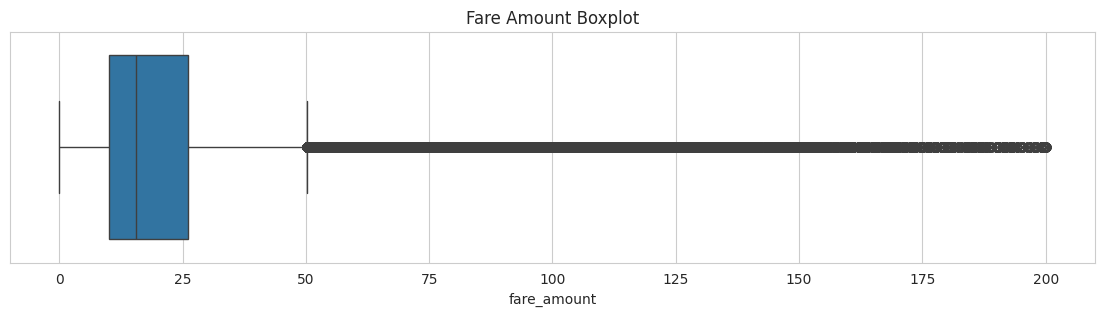

In [23]:
plt.figure(figsize=(14, 3))

sns.boxplot(
    x=df["fare_amount"]
)

plt.title(
    "Fare Amount Boxplot"
)

plt.show()

In [24]:
Q1 = df["fare_amount"].quantile(0.25)

Q3 = df["fare_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = (
    Q1
    - 1.5 * IQR
)

upper_bound = (
    Q3
    + 1.5 * IQR
)

print(
    "Lower Bound:",
    lower_bound
)

print(
    "Upper Bound:",
    upper_bound
)

outliers = df[
    (
        df["fare_amount"]
        < lower_bound
    )
    |
    (
        df["fare_amount"]
        > upper_bound
    )
]

print(
    "Number of Outliers:",
    len(outliers)
)

Lower Bound: -14.150000000000002
Upper Bound: 50.25
Number of Outliers: 228465


### Observation

A number of extreme fare observations were identified.

These observations may represent exceptionally long trips or data inconsistencies and should be treated appropriately during preprocessing.

# 6. Correlation Analysis

Correlation analysis helps quantify linear relationships between numerical variables and fare amount.

In [25]:
numerical_features = [
    "fare_amount",
    "trip_distance",
    "trip_duration",
    "passenger_count",
    "cbd_congestion_fee"
]

corr_matrix = (
    df[numerical_features]
    .corr()
)

corr_matrix

,fare_amount,trip_distance,trip_duration,passenger_count,cbd_congestion_fee
fare_amount,1.000000,0.859182,0.745951,0.013056,-0.064541
trip_distance,0.859182,1.000000,0.750048,0.022731,-0.140253
trip_duration,0.745951,0.750048,1.000000,-0.010033,-0.088138
passenger_count,0.013056,0.022731,-0.010033,1.000000,0.031816
cbd_congestion_fee,-0.064541,-0.140253,-0.088138,0.031816,1.000000


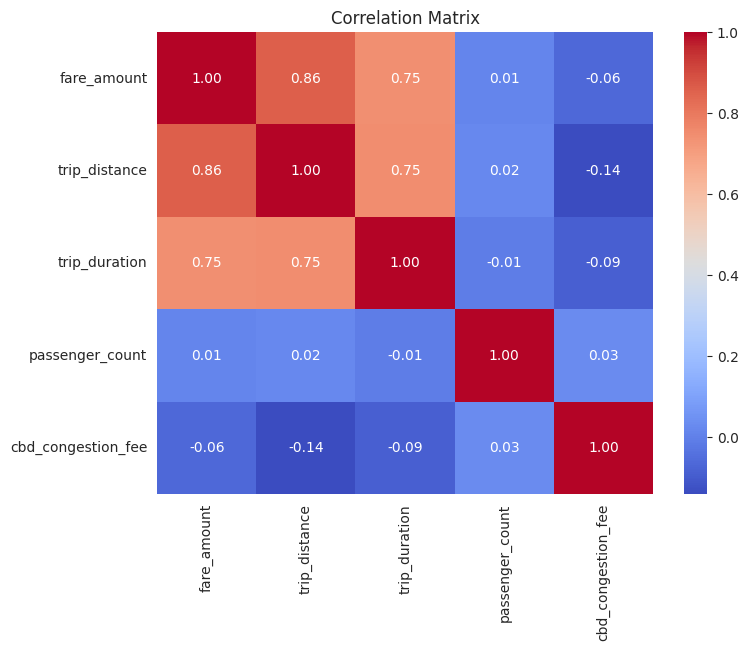

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

### Observation

- Features exhibiting strong correlation with fare amount are potential predictors.
- Trip distance is expected to show the strongest relationship with fare.
- Trip duration may also exhibit strong correlation but cannot be used due to data leakage concerns.

# 7. Relationship Between Trip Distance and Fare Amount

Investigate whether longer trips generally result in higher fares.

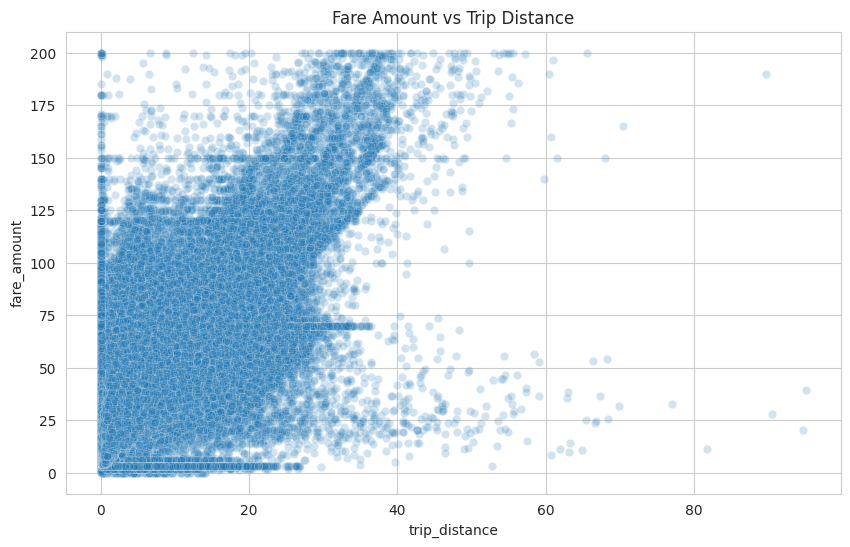

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="trip_distance",
    y="fare_amount",
    alpha=0.2
)

plt.title(
    "Fare Amount vs Trip Distance"
)

plt.show()

### Observation

A strong positive relationship exists between trip distance and fare amount, supporting its inclusion as a predictive feature.

# 8. Temporal Analysis: Pickup Hour

Analyze whether average fares vary across different hours of the day.

In [28]:
temp_df = df.copy()

temp_df[
    "tpep_pickup_datetime"
] = pd.to_datetime(
    temp_df[
        "tpep_pickup_datetime"
    ]
)

temp_df[
    "pickup_hour"
] = (
    temp_df[
        "tpep_pickup_datetime"
    ]
    .dt.hour
)

In [29]:
hourly_fares = (
    temp_df
    .groupby(
        "pickup_hour"
    )["fare_amount"]
    .mean()
)

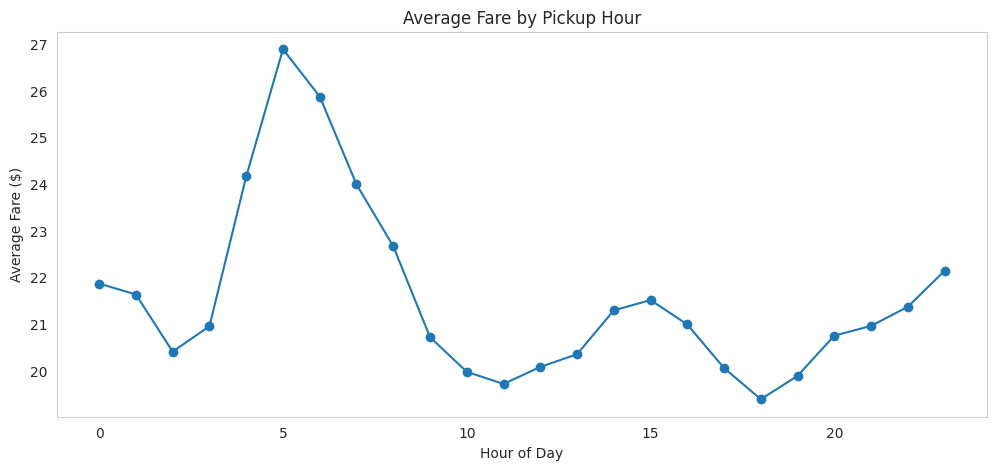

In [30]:
plt.figure(figsize=(12, 5))

hourly_fares.plot(
    marker="o"
)

plt.title(
    "Average Fare by Pickup Hour"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Average Fare ($)"
)

plt.grid()

plt.show()

### Observation

Variations in average fare across different times of the day suggest that temporal factors influence pricing patterns.

Therefore, pickup hour may provide predictive value.

# 9. Geographical Analysis

Examine whether pickup and dropoff locations influence fare behavior.

In [31]:
top_pickups = (
    df.groupby(
        "PULocationID"
    )["fare_amount"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(20)
)

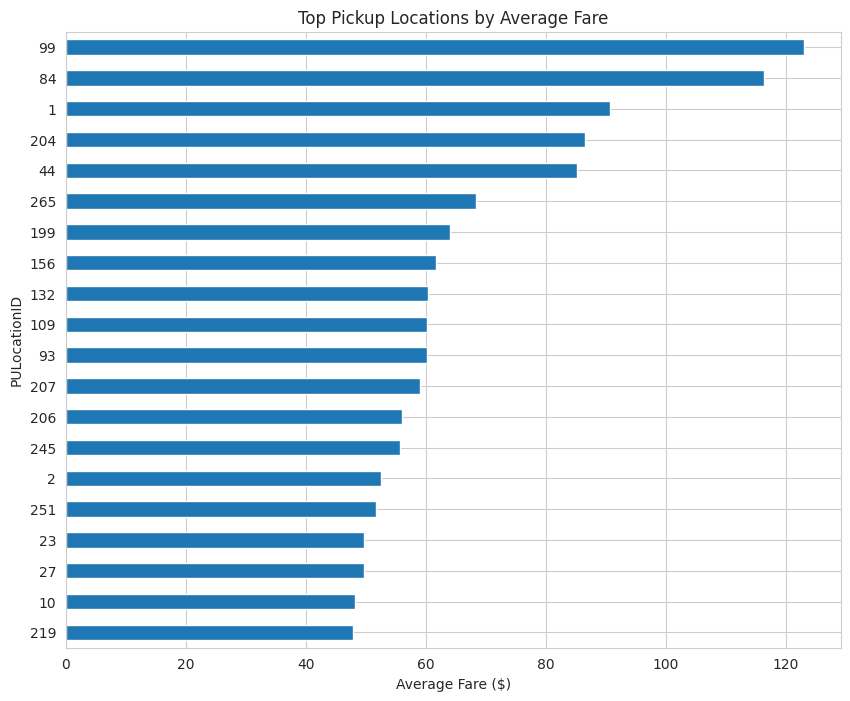

In [32]:
plt.figure(figsize=(10, 8))

top_pickups.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Pickup Locations by Average Fare"
)

plt.xlabel(
    "Average Fare ($)"
)

plt.show()

In [33]:
top_dropoffs = (
    df.groupby(
        "DOLocationID"
    )["fare_amount"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(20)
)

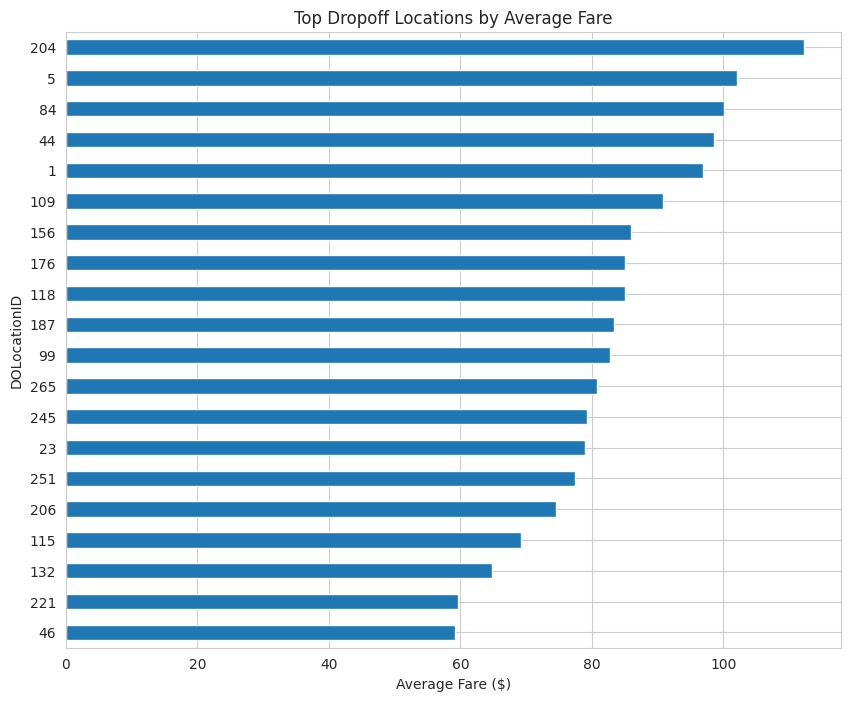

In [34]:
plt.figure(figsize=(10, 8))

top_dropoffs.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top Dropoff Locations by Average Fare"
)

plt.xlabel(
    "Average Fare ($)"
)

plt.show()

### Observation

Substantial differences in average fares across locations indicate that geographical information contributes significantly to fare estimation.

# 10. Feature Selection Decisions

Based on EDA findings:

### Selected Features

- passenger_count
- trip_distance
- RatecodeID
- cbd_congestion_fee
- pickup_hour
- pickup_dayofweek
- PULocationID
- DOLocationID

### Engineered Features

- is_weekend
- is_rush_hour
- Location_Pair

### Excluded Features

- trip_duration

Although trip duration exhibited strong correlation with fare amount, it was excluded because it is unavailable before ride initiation and would introduce data leakage.

# EDA Conclusion

1. Fare amount exhibited a positively skewed distribution with several extreme observations.

2. Trip distance demonstrated the strongest relationship with fare amount.

3. Temporal characteristics influenced average fare behavior.

4. Pickup and dropoff locations exhibited substantial variability in fare patterns.

5. Trip duration showed strong correlation with fare amount but was excluded to prevent data leakage.

These insights guided the feature engineering and model development process for fare prediction.

---